In [27]:
############### IMPORTING NEEDED MODULES FOR THE SCRIPT ###############
from operator import index
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statistics
import sys
#from HNSC_immunescore import get_corr_pvals_IS
sys.path.append("E:/Immune_Evasion_Project/Mario/Scripts_Python")

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import roc_auc_score, f1_score
import sklearn.metrics as metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import scale 

In [28]:
############### IMPORTING FUNCTIONS LIBRARY ###############

# We will import the 'Functions' library from our directory, make sure the file is present in the defined Directory above.
import Functions_Mario
from Functions_Mario import *

import Functions
from Functions import *

# This is for reloading the Library above. 
# import importlib
# importlib.reload(Functions_Mario)

In [29]:
############### IMPORTING REQUIRED DATA ###############

HNSC_model = pd.read_csv("E:/Immune_Evasion_Project/Output/HNSC_model.csv", index_col=0)
HNSC_allparams =  pd.read_csv("E:/Immune_Evasion_Project/Mario/Cancer_Types/HNSC/HNSC_allgenes_parameters.csv", index_col=0)
pos_controls = pd.read_csv("E:/Immune_Evasion_Project/Dania/Control_genes/HNSC_pos_controls_parameters.csv", index_col=0)
neg_controls = pd.read_csv("E:/Immune_Evasion_Project/Dania/Control_genes/HNSC_neg_controls_parameters.csv", index_col=0)

In [30]:
# prepare data for logreg
neg_only = neg_controls
pos_only = pos_controls
mix_x = pd.concat([neg_only.iloc[:, 0:5],pos_only.iloc[:, 0:5]])
mix_y = pd.concat([neg_only.iloc[:,5],pos_only.iloc[:,5]])

mix = pd.concat([neg_only, pos_only])

In [31]:
y = mix_y
x = mix_x #.iloc[:,[0,1,2,3,4]]

In [32]:
# FOR CROSS VAL
# getting train, test split for all data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify = y)

In [33]:
# fit the model with ALL variables and calculate auc score
clf_logistic = LogisticRegression(penalty = "none", max_iter=10000).fit(x_train,y_train)
preds = clf_logistic.predict_proba(x_test)[:,1] # only get prob of output being 1. 
pred = clf_logistic.predict(x_test)
#Using predict_proba vs predict will allow us to set a threshold to call it as 1 or 0

print(roc_auc_score(y_test, preds)) # choosing predict_proba instead of predict since we want to change the threshold to >0.5 to say its positive
# these scores can only be calculated using binary predictions and not pred probabilities
p = precision_score(y_test, pred)
r = recall_score(y_test, pred)
f = f1_score(y_test, pred)
print(f)

0.7761904761904762
0.7142857142857142


In [34]:
### USING ROC AUC ####
fpr, tpr, thresholds = metrics.roc_curve(y_test, preds)
auc = metrics.auc(fpr, tpr)

Best Threshold=0.491362, G-Mean=0.759


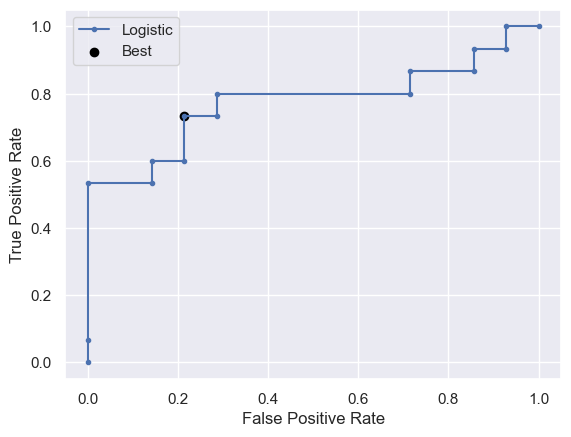

In [35]:
# calculate the g-mean for each threshold (sensitivity * specificity)
from numpy import sqrt, argmax,argmin
gmeans = sqrt(tpr * (1-fpr))
# locate the index of the largest g-mean
ix = argmax(gmeans)
print('Best Threshold=%f, G-Mean=%.3f' % (thresholds[ix], gmeans[ix]))
# plot the roc curve for the model
#plt.plot([0,1], [0,1], linestyle='--', label='No Skill')
sns.set(font_scale=1)
plt.plot(fpr, tpr, marker='.', label='Logistic')
plt.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
# show the plot
plt.show()

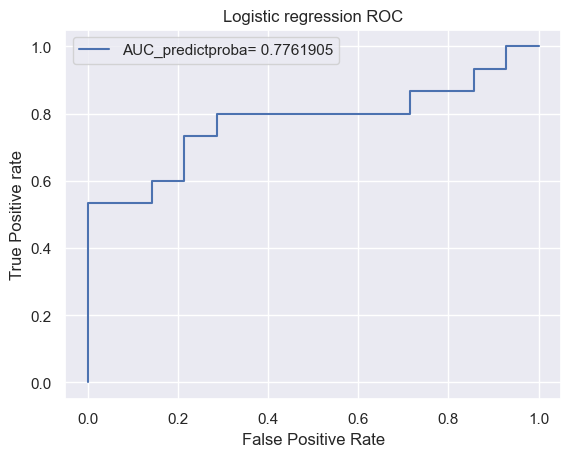

In [36]:
plt.plot(fpr, tpr, label = 'AUC_predictproba= %0.7f' % auc)
plt.title('Logistic regression ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')

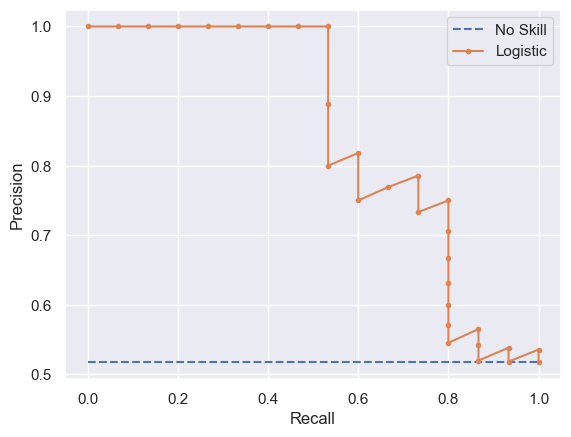

In [37]:
#### USING PRECISION RECALL CURVE ####
from sklearn.metrics import (precision_recall_curve, PrecisionRecallDisplay)

precision, recall, thresholds = precision_recall_curve(y_test, preds)
# plot the roc curve for the model
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.plot([0,1], [no_skill,no_skill], linestyle='--', label='No Skill')
plt.plot(recall, precision, marker='.', label='Logistic')
# axis labels
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
# show the plot
plt.show()

Best Threshold=0.468032, F-Score=0.774


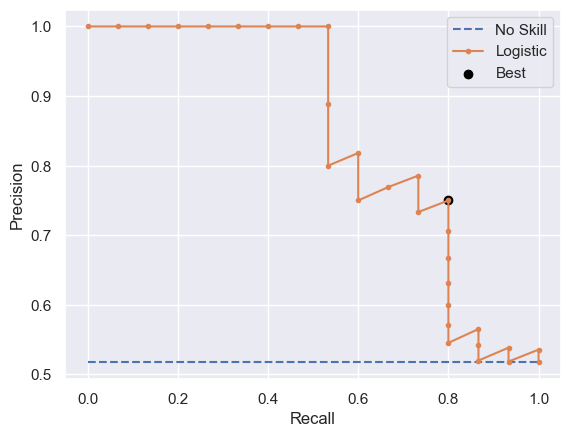

In [38]:
# finding the best threshold using precision and recall (using F-score)
# convert to f score
fscore = (2 * precision * recall) / (precision + recall)
# locate the index of the largest f score
ix = argmax(fscore)
print('Best Threshold=%f, F-Score=%.3f' % (thresholds[ix], fscore[ix]))
# plot the roc curve for the model
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.plot([0,1], [no_skill,no_skill], linestyle='--', label='No Skill')
plt.plot(recall, precision, marker='.', label='Logistic')
plt.scatter(recall[ix], precision[ix], marker='o', color='black', label='Best')
# axis labels
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
# show the plot
plt.show()

In [39]:
# define thresholds
from numpy import arange
thresholds = arange(0, 1, 0.001)
# apply threshold to positive probabilities to create labels
def to_labels(pos_probs, threshold):
	return (pos_probs >= threshold).astype('int')
# evaluate each threshold
scores = [f1_score(y_test, to_labels(preds, t)) for t in thresholds]
# get best threshold
ix = argmax(scores)
print('Threshold=%.3f, F-Score=%.5f' % (thresholds[ix], scores[ix]))

Threshold=0.465, F-Score=0.77419


In [40]:
import statsmodels.api as sm

#define response variable
yy= y_train
#define predictor variables
xx = x_train
#add constant to predictor variables
xx = sm.add_constant(xx)

#fit linear regression model
log_reg = sm.Logit(yy, xx).fit()
#view model summary
print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.546729
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  class   No. Observations:                  113
Model:                          Logit   Df Residuals:                      107
Method:                           MLE   Df Model:                            5
Date:                Thu, 16 Mar 2023   Pseudo R-squ.:                  0.2108
Time:                        13:30:13   Log-Likelihood:                -61.780
converged:                       True   LL-Null:                       -78.286
Covariance Type:            nonrobust   LLR p-value:                 3.745e-06
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -1.1351      0.513     -2.210      0.027

In [41]:
# LASSO
from numpy import arange

alphas = 10**np.linspace(10,-2,100)*0.5 # arange(0, 0.01, 0.001) 

lasso = LogisticRegression(penalty="l1",
    solver="liblinear",)
#Lasso(max_iter = 10000, normalize = True)
coefs = []

for a in alphas:
    lasso.set_params(C=a) # C is Inverse of regularization strength; smaller values specify stronger regularization.
    lasso.fit(scale(x_train), y_train)
    coefs.append(lasso.coef_.ravel().copy())

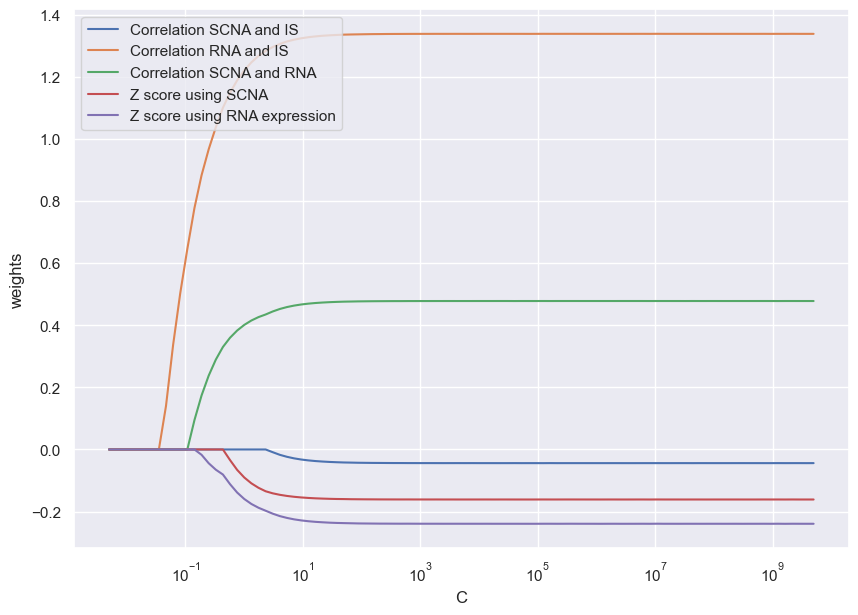

In [42]:
fig = plt.figure(figsize=(10,7))
ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('C')
plt.ylabel('weights')
plt.legend([ "Correlation SCNA and IS", "Correlation RNA and IS", "Correlation SCNA and RNA" ,"Z score using SCNA", "Z score using RNA expression"], loc="best")
#["SCNA_IS_unfiltered", "freqdel", "SCNA_RNA", "RNA_IS", "CCLE_SCNA_RNA", "CCLE_SCNA_prot", "survival_loss", "survival_gain", "survival_exp"])
#[ "corr SCNA and IS", "freq of deletion", "corr SCNA and RNA", "corr RNA and IS", "survival z score_loss","survival z score_gain", "survival z scorel_exp"])

#roc_auc_score(y_test, preds)

In [43]:
lassocv = LogisticRegressionCV(Cs=10, cv=3,penalty="l1", scoring="f1", solver="liblinear")
lassocv.fit(x_train, y_train) # solver already chooses the best alpha

lassocv_roc = LogisticRegressionCV(Cs=10, cv=3,penalty="l1", scoring="roc_auc", solver="liblinear")
lassocv_roc.fit(x_train, y_train) 


print("The best C chosen is", lassocv.C_)
print("coefficients:", lassocv.coef_)
print("coefficients_roc:", lassocv_roc.coef_)

print("roc_auc_score:",roc_auc_score(lassocv_roc.predict(x_test), y_test))
print("f1 score:",f1_score(lassocv.predict(x_test), y_test))

The best C chosen is [166.81005372]
coefficients: [[-0.29503816  5.30714763  3.09336742 -0.18111585 -0.20003082]]
coefficients_roc: [[-0.32445568  5.32289673  3.12201367 -0.18041982 -0.20045285]]
roc_auc_score: 0.7283653846153846
f1 score: 0.7142857142857142


<AxesSubplot: >

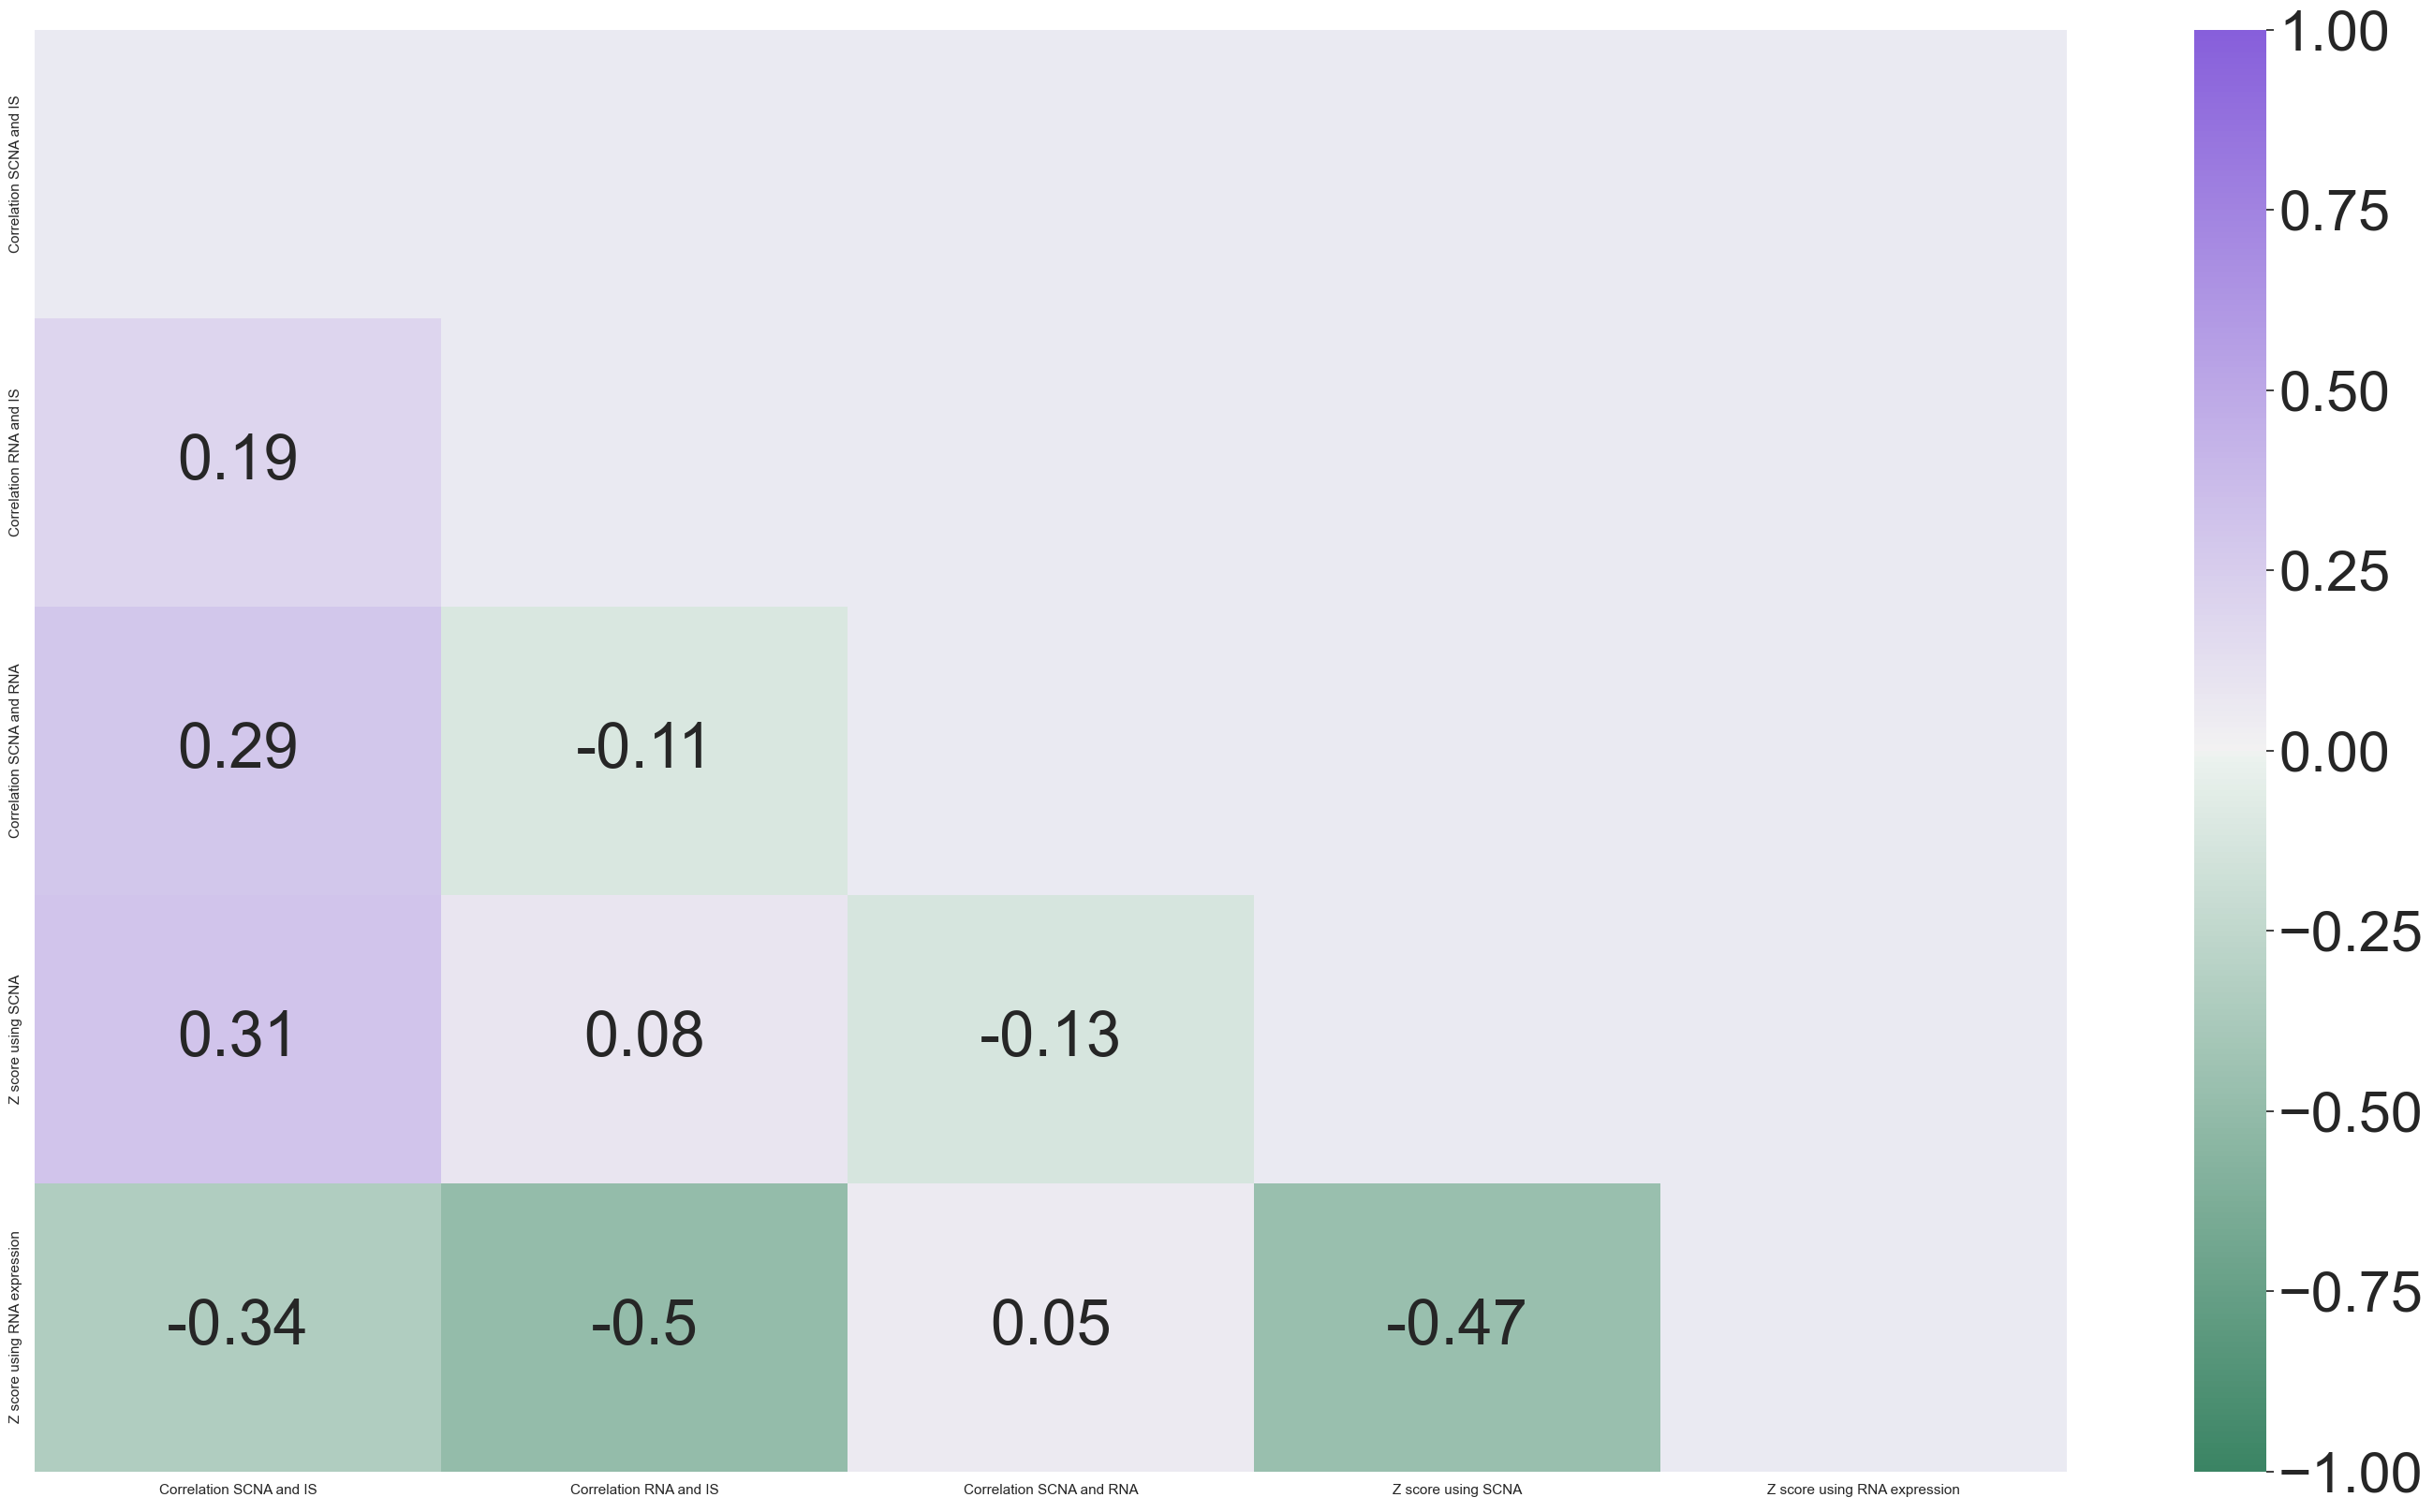

In [44]:
# CORRELATION MATRIX
corr_matrix = mix_x.corr(method = "spearman").round(2) # get corr, then round up to 2 decimal
mask = np.zeros_like(corr_matrix) # build matrix - get an array of zeros with same shape as corr_matrix  
mask[np.triu_indices_from(mask)] = True # mask (hide) the upper triangle
fig, ax = plt.subplots(figsize=(35,20))
sns.set(font_scale=4)
cmap = sns.diverging_palette(150, 275, as_cmap=True)
sns.heatmap(corr_matrix, mask = mask, annot=True, # The Seaborn heatmap ‘mask’ argument comes in handy when we want to cover part of the heatmap.
            cmap= cmap, vmin=-1, vmax=1)


In [45]:
# calculating VIF for MULTICOLLINIEARTIYT
#REMOVE high and calculate again
from statsmodels.stats.outliers_influence import variance_inflation_factor
# VIF dataframe
X = mix_x[["Correlation SCNA and IS",  "Correlation SCNA and RNA", "Correlation RNA and IS","Z score using SCNA", "Z score using RNA expression"]]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
  
# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

In [46]:
## PREDICTIONS ##
all_params_rmNA = HNSC_model.dropna()
# create df for inference
real_preds = clf_logistic.predict_proba(all_params_rmNA)[:,1]

c:\Users\jmari\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: FutureWarning: The feature names should match those that were passed during fit. Starting version 1.2, an error will be raised.
Feature names unseen at fit time:
- Corr_RNA_IS
- Corr_SCNA_IS
- Corr_SCNA_RNA
- Z-score_Exp
- Z-score_Loss
Feature names seen at fit time, yet now missing:
- Correlation RNA and IS
- Correlation SCNA and IS
- Correlation SCNA and RNA
- Z score using RNA expression
- Z score using SCNA

  warnings.warn(message, FutureWarning)


In [47]:
#first create dict
preds_dict = {}
for i in range(0,len(real_preds)):
    dict_vals = {all_params_rmNA.index[i]: real_preds[i]}
    preds_dict.update(dict_vals)

# then df
realpreds_df = pd.DataFrame(index = all_params_rmNA.index, columns = ["predict_prob", "class_outcome"])
realpreds_df["predict_prob"] = preds_dict.values()

for i in range(0,len(realpreds_df)):
    if realpreds_df.predict_prob[i] > 0.9:
        realpreds_df.class_outcome[i] = 1
    else:
       realpreds_df.class_outcome[i] = 0

C:\Users\jmari\AppData\Local\Temp\ipykernel_24668\3186721055.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  realpreds_df.class_outcome[i] = 0
C:\Users\jmari\AppData\Local\Temp\ipykernel_24668\3186721055.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  realpreds_df.class_outcome[i] = 1


In [48]:
realpreds_pos = realpreds_df[realpreds_df.class_outcome == 1] # predicted positives
realpreds_params = HNSC_model[HNSC_model.index.isin(realpreds_df.index)]
realpredspos_params = HNSC_model[HNSC_model.index.isin(realpreds_pos.index)]

In [49]:
realpreds_pos

,predict_prob,class_outcome
Gene-Symbol,,
TNFRSF14,0.917515,1
TNFRSF1B,0.943262,1
C1QC,0.900023,1
ZNF683,0.914572,1
LCK,0.915807,1
...,...,...
WAS,0.954786,1
IL2RG,0.926380,1
CXCR3,0.952676,1


In [51]:
realpreds_params


,Corr_SCNA_IS,Corr_SCNA_RNA,Corr_RNA_IS,Z-score_Loss,Z-score_Exp
Gene-Symbol,,,,,
ACAP3,0.156631,0.240208,-0.069443,-0.373846,-2.101157
ACTRT2,0.156631,-0.060760,-0.020883,-0.373846,-0.489267
AGRN,0.156631,0.337847,-0.025855,-0.373846,1.139579
ATAD3A,0.156631,0.249805,-0.096540,-0.373846,-0.117732
ATAD3B,0.156631,0.203738,-0.021544,-0.373846,-1.212699
...,...,...,...,...,...
MPP1,0.173814,0.129590,0.489168,0.982581,-0.276836
MTCP1,0.173814,-0.068053,-0.176841,0.982581,0.396790
RAB39B,0.173814,-0.023870,0.654264,0.982581,-0.402926


In [52]:
realpredspos_params

,Corr_SCNA_IS,Corr_SCNA_RNA,Corr_RNA_IS,Z-score_Loss,Z-score_Exp
Gene-Symbol,,,,,
TNFRSF14,0.156631,0.183609,0.744001,-0.373846,-1.115476
TNFRSF1B,0.173087,0.174739,0.832989,-0.450945,-1.925081
C1QC,0.169286,0.144898,0.771297,-0.741118,-0.353188
ZNF683,0.165943,0.153075,0.855744,-0.487103,0.093996
LCK,0.142122,0.130729,0.827435,-0.312873,-1.138236
...,...,...,...,...,...
WAS,0.288530,0.262223,0.880171,0.967935,-1.523441
IL2RG,0.215377,0.160597,0.883153,1.296582,-1.769716
CXCR3,0.214506,0.208984,0.939620,1.332876,-1.978518
